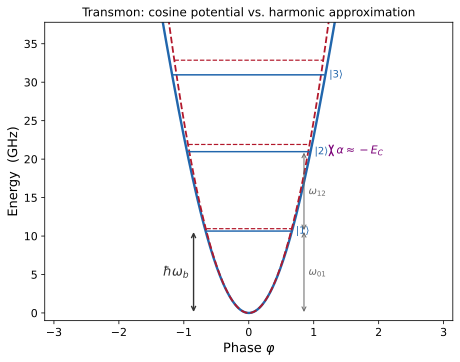

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scqubits as scq

# --- Parameters (deep transmon regime EJ/EC ~ 167) ---
EJ = 50.0   # GHz
EC = 0.3    # GHz

tmon = scq.Transmon(EJ=EJ, EC=EC, ng=0.0, ncut=40)

# --- Eigenvalues (first 5 levels, ground state → 0) ---
evals = tmon.eigenvals(evals_count=5)
evals -= evals[0]

omega_p = np.sqrt(8 * EJ * EC)
E_harm = np.array([omega_p * n for n in range(5)])

# --- Phase grid (single well) ---
phi = np.linspace(-np.pi, np.pi, 501)
V_cos  = EJ * (1 - np.cos(phi))
V_harm = 0.5 * EJ * phi**2

# --- Figure ---
fig, ax = plt.subplots(figsize=(6.5, 5.2))

ax.plot(phi, V_cos,  color='#2166ac', lw=2.4,
        label=r'$E_J(1-\cos\varphi)$')
ax.plot(phi, V_harm, color='#b2182b', lw=1.8, ls='--',
        label=r'$\frac{1}{2}E_J\varphi^2$  (harmonic)')

# --- Energy levels (n = 0 … 3) ---
for n in range(4):
    E_c = evals[n]
    E_h = E_harm[n]

    # turning points in cosine potential
    mask_c = V_cos <= E_c
    phi_c  = phi[mask_c]

    # turning points in harmonic potential (use harmonic energy)
    mask_h = V_harm <= E_h
    phi_h  = phi[mask_h]

    # cosine levels (solid blue, bounded by cosine turning points)
    if len(phi_c) > 1:
        ax.hlines(E_c, phi_c[0], phi_c[-1],
                  colors='#2166ac', lw=1.5, zorder=3)

    # harmonic levels (dashed red, bounded by harmonic turning points)
    # skip n=0 since both are at 0
    if n > 0 and len(phi_h) > 1:
        ax.hlines(E_h, phi_h[0], phi_h[-1],
                  colors='#b2182b', lw=1.2, ls='--', zorder=3)

    # label on the right of the cosine level
    if len(phi_c) > 1:
        ax.text(phi_c[-1] + 0.07, E_c, rf'$|{n}\rangle$',
                fontsize=10, va='center', color='#2166ac')

# --- Annotate ω_b: double arrow between |0⟩ and |1⟩ on the LEFT side ---
omega_01 = evals[1]
omega_12 = evals[2] - evals[1]
alpha    = omega_12 - omega_01

x_wb = -0.85
ax.annotate('', xy=(x_wb, evals[1]), xytext=(x_wb, evals[0]),
            arrowprops=dict(arrowstyle='<->', color='#333333', lw=1.4,
                            shrinkA=1, shrinkB=1))
ax.text(x_wb - 0.07, 0.5 * (evals[0] + evals[1]),
        r'$\hbar\omega_b$', fontsize=13, ha='right', va='center',
        color='#333333')

# --- Annotate α: double arrow between |1⟩→|2⟩ spacing vs |0⟩→|1⟩ spacing
#     Visually: show as the gap between the harmonic |2⟩ (dashed) and
#     the cosine |2⟩ (solid).  Harmonic is higher, cosine is lower,
#     and the difference is 2α (accumulated from two transitions). ---
#     Instead, annotate α directly between levels |1⟩→|2⟩ and |0⟩→|1⟩
#     by showing two brackets on the RIGHT side.
x_a = 0.85

# bracket for ω_01
ax.annotate('', xy=(x_a, evals[1]), xytext=(x_a, evals[0]),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.0,
                            shrinkA=1, shrinkB=1))
ax.text(x_a + 0.07, 0.5 * (evals[0] + evals[1]),
        r'$\omega_{01}$', fontsize=10, ha='left', va='center', color='#666666')

# bracket for ω_12
ax.annotate('', xy=(x_a, evals[2]), xytext=(x_a, evals[1]),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.0,
                            shrinkA=1, shrinkB=1))
ax.text(x_a + 0.07, 0.5 * (evals[1] + evals[2]),
        r'$\omega_{12}$', fontsize=10, ha='left', va='center', color='#666666')

# curly-brace style: annotate α as the difference
ax.annotate('',
            xy=(x_a + 0.42, evals[1] + omega_12),
            xytext=(x_a + 0.42, evals[1] + omega_01),
            arrowprops=dict(arrowstyle='<->', color='#7a0177', lw=1.3,
                            shrinkA=1, shrinkB=1))
ax.text(x_a + 0.50, evals[1] + 0.5 * (omega_01 + omega_12),
        r'$\alpha \approx -E_C$', fontsize=11, ha='left', va='center',
        color='#7a0177')

# --- Cosmetics ---
ax.set_xlabel(r'Phase $\varphi$', fontsize=13)
ax.set_ylabel(r'Energy  (GHz)', fontsize=13)
ax.set_xlim(-np.pi, np.pi)
ymax = max(evals[3], E_harm[3]) * 1.15
ax.set_ylim(-1, ymax)
ax.set_title('Transmon: cosine potential vs. harmonic approximation', fontsize=12)
ax.tick_params(labelsize=11)
fig.tight_layout()
fig.savefig('transmon_potential.pdf', bbox_inches='tight')
plt.show()

Spectral data:   0%|          | 0/101 [00:00<?, ?it/s]

Spectral data:   0%|          | 0/101 [00:00<?, ?it/s]

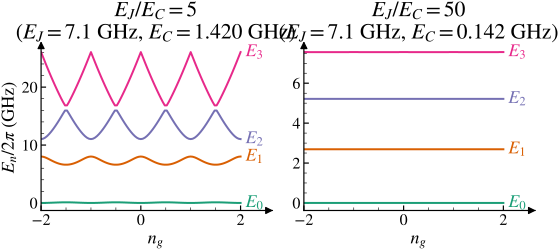

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scqubits as scq

# ==============================================================================
# Apply "small_plot" style based on polish_plot
# ==============================================================================
sz = 4.0
mpl.rcParams.update({
    # We use (2 * sz, sz) since there are 2 subplots side-by-side
    "figure.figsize": (sz * 2, sz), 
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "font.family": "STIXGeneral",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "mathtext.fontset": "stix",

    "lines.linewidth": 2.0,
    "lines.markersize": 5.0,

    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 3.0,
    "ytick.minor.size": 3.0,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.grid": False,
    
    "svg.fonttype": "path",
    "pdf.fonttype": 42
})

def add_axis_arrows(ax, arrow_lw=1.2, arrow_color="black", arrow_scale=1.5):
    """Add arrowheads to x/y axis ends in axes coordinates."""
    ax.annotate("", xy=(1.02, 0.0), xytext=(1.0, 0.0), xycoords="axes fraction", textcoords="axes fraction", arrowprops=dict(arrowstyle="-|>", lw=arrow_lw, color=arrow_color, mutation_scale=10 * arrow_scale))
    ax.annotate("", xy=(0.0, 1.02), xytext=(0.0, 1.0), xycoords="axes fraction", textcoords="axes fraction", arrowprops=dict(arrowstyle="-|>", lw=arrow_lw, color=arrow_color, mutation_scale=10 * arrow_scale))
# ==============================================================================

n_levels = 4
EJ_EC_ratios = [5.0, 50.0]

# Set fixed EJ to 7.1 GHz
EJ = 7.1

colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e']

fig, axes = plt.subplots(1, len(EJ_EC_ratios), sharey=False)

for ax_idx, ratio in enumerate(EJ_EC_ratios):
    # Calculate EC based on the fixed EJ and desired ratio
    EC = EJ / ratio
    
    tmon = scq.Transmon(EJ=EJ, EC=EC, ng=0.0, ncut=30)

    ng_vals = np.linspace(-2, 2, 101)
    
    # 1. Get absolute energies by setting subtract_ground=False
    specdata = tmon.get_spectrum_vs_paramvals(
        'ng', ng_vals, evals_count=n_levels, subtract_ground=False
    )

    ax = axes[ax_idx]
    
    # 2. Get the absolute ground state energy at ng = -2.
    E0_at_minus_2 = specdata.energy_table[0, 0]
    
    # 3. Plot by subtracting this constant offset from all energies
    for n in range(n_levels):
        y_vals = specdata.energy_table[:, n] - E0_at_minus_2
        ax.plot(ng_vals, y_vals, color=colors[n])
        
        # Direct labeling on the right side of the curve
        ax.text(ng_vals[-1] + 0.1, y_vals[-1], rf'$E_{n}$', color=colors[n], va='center', ha='left')

    ax.set_xlabel(r'$n_g$')
    ax.set_title(rf'$E_J/E_C = {ratio:.0f}$' + '\n' + rf'($E_J={EJ:.1f}$ GHz, $E_C={EC:.3f}$ GHz)')
    
    # Expand x-limit slightly to make room for the right-side direct labels
    ax.set_xlim(ng_vals[0], ng_vals[-1] + 0.6)
    
    add_axis_arrows(ax)

# 4. Updated Y-axis label as requested
axes[0].set_ylabel(r'$E_n/2\pi$ (GHz)')

fig.tight_layout()
fig.savefig('transmon_charge_dispersion.pdf')
plt.show()


Spectral data:   0%|          | 0/101 [00:00<?, ?it/s]

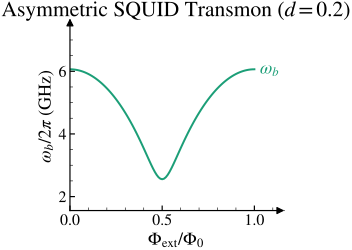

In [5]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scqubits as scq

# ==============================================================================
# Apply "small_plot" style based on polish_plot
# ==============================================================================
sz = 4.0
mpl.rcParams.update({
    "figure.figsize": (sz, sz), # Standard 1-panel square figure
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "font.family": "STIXGeneral",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "mathtext.fontset": "stix",

    "lines.linewidth": 2.0,
    "lines.markersize": 5.0,

    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 3.0,
    "ytick.minor.size": 3.0,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.grid": False,
    
    "svg.fonttype": "path",
    "pdf.fonttype": 42
})

def add_axis_arrows(ax, arrow_lw=1.2, arrow_color="black", arrow_scale=1.5):
    """Add arrowheads to x/y axis ends in axes coordinates."""
    ax.annotate("", xy=(1.02, 0.0), xytext=(1.0, 0.0), xycoords="axes fraction", textcoords="axes fraction", arrowprops=dict(arrowstyle="-|>", lw=arrow_lw, color=arrow_color, mutation_scale=10 * arrow_scale))
    ax.annotate("", xy=(0.0, 1.02), xytext=(0.0, 1.0), xycoords="axes fraction", textcoords="axes fraction", arrowprops=dict(arrowstyle="-|>", lw=arrow_lw, color=arrow_color, mutation_scale=10 * arrow_scale))
# ==============================================================================

# Transmon parameters
EJmax = 20.0  # Maximum Josephson Energy in GHz (sum of EJ1 and EJ2)
EC = 0.25     # Charging energy in GHz
d = 0.2       # Asymmetry parameter: d = (E_J1 - E_J2) / (E_J1 + E_J2)

tmon_tunable = scq.TunableTransmon(
    EJmax=EJmax,
    EC=EC,
    d=d,
    flux=0.0,
    ng=0.0,
    ncut=30
)

# Flux sweep from 0 to 1
flux_vals = np.linspace(0.0, 1.0, 101)

# Calculate spectrum vs flux. subtract_ground=True sets the ground state E_0 to 0.
specdata = tmon_tunable.get_spectrum_vs_paramvals(
    'flux', flux_vals, evals_count=2, subtract_ground=True
)

# omega_b (or omega_01) is the first excited state energy, effectively E_1 - E_0
omega_b = specdata.energy_table[:, 1]

fig, ax = plt.subplots()
colors = ['#1b9e77', '#d95f02', '#7570b3']

# Plot the transition frequency vs flux
ax.plot(flux_vals, omega_b, color=colors[0])

# Direct label for the curve at the end (Φ = 1.0)
ax.text(flux_vals[-1] + 0.03, omega_b[-1], r'$\omega_{b}$', color=colors[0], va='center', ha='left')

# Axis labels and title
ax.set_xlabel(r'$\Phi_{\mathrm{ext}} / \Phi_0$')
ax.set_ylabel(r'$\omega_b / 2\pi$ (GHz)')
ax.set_title(rf'Asymmetric SQUID Transmon ($d={d}$)')

# Set limits, giving slightly more room on the x-axis for the label text
ax.set_xlim(0.0, 1.15)

y_min = np.min(omega_b) - 1.0
y_max = np.max(omega_b) + 1.5
ax.set_ylim(y_min, y_max)

add_axis_arrows(ax)

fig.tight_layout()
fig.savefig('tunable_transmon_frequency_vs_flux.pdf')
plt.show()
